# Phase 5: Negative Binomial Regression with Autoregressive Terms (NB-AR)
---

**Model comparison:**
- **Model 1 (Baseline):** Rainfall + Season only (rainfall lag, cumulative rainfall, rainy days, three seasonal indicators)
- **Model 2 (NB-AR):** Baseline + two autoregressive dengue terms (`Dengue_Lag1`, `Dengue_Lag2`)

**Benchmark:**
- **Naive predictor:** `Dengue_Lag1` only (predict this week = last week)

**Diagnostics:** Variance inflation factor (VIF), Ljung–Box residual test, ACF/PACF plots, Poisson vs NB likelihood ratio, COVID sensitivity analysis, formal zone interaction test.

**Input:** `phase2b_output_with_lags.csv`

## 5.1 Setup

In [1]:
!pip install -q pandas numpy matplotlib seaborn scipy statsmodels scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

## 5.2 Load Data

In [2]:
print('Upload: phase2b_output_with_lags.csv')
uploaded = files.upload()
input_file = list(uploaded.keys())[0]
merged = pd.read_csv(input_file)

# Drop NAs on variables used in modelling (not on all columns)
used = ['Dengue_Cases','Weekly_Mean_Rainfall','Rainy_Days',
        'Rainfall_Cum4w_Lag1','Dengue_Lag1','Dengue_Lag2'] + \
       [f'Rainfall_Lag{i}' for i in range(1,13)]
complete = merged.dropna(subset=used).copy()
print(f'Complete cases for modelling: {complete.shape}')

Upload: phase2b_output_with_lags.csv


Saving phase2b_output_with_lags (10).csv to phase2b_output_with_lags (10).csv
Complete cases for modelling: (496, 30)


In [3]:
# Defensive check: create seasonal indicators if not already present
# (These are normally created in Phase 2b, but this block makes Phase 5
#  self-contained and readable in isolation.)

if 'Season_SW' not in merged.columns:
    def assign_season(week):
        if 19 <= week <= 39:
            return 'SW'
        elif week >= 48 or week <= 9:
            return 'NE'
        else:
            return 'Inter'
    merged['Season'] = merged['Week'].apply(assign_season)
    merged['Season_SW'] = (merged['Season'] == 'SW').astype(int)
    merged['Season_NE'] = (merged['Season'] == 'NE').astype(int)
    merged['Season_Inter'] = (merged['Season'] == 'Inter').astype(int)
    print('Created seasonal indicators in Phase 5 (were not present in input).')
else:
    print('Seasonal indicators already present from Phase 2b input.')

Seasonal indicators already present from Phase 2b input.


## 5.3 Train–Test Split (Temporal, 80/20)

In [4]:
# Train on 2020–2023; test on 2024 (held-out future year)
train = complete[complete['Year'].isin([2020,2021,2022,2023])].copy()
test  = complete[complete['Year']==2024].copy()

print(f'Training: {train.shape[0]} obs  |  Test: {test.shape[0]} obs')
for moh in ['Balangoda','Udawalawa']:
    print(f'  {moh}: train = {len(train[train["MOH"]==moh])}, test = {len(test[test["MOH"]==moh])}')

Training: 392 obs  |  Test: 104 obs
  Balangoda: train = 196, test = 52
  Udawalawa: train = 196, test = 52


## 5.4 Feature Selection — Optimal Rainfall Lag per MOH

In [5]:
# Select the strongest significant Spearman rainfall lag for each MOH area (training set only)
best_lags = {}
for moh in ['Balangoda', 'Udawalawa']:
    subset = train[train['MOH']==moh]
    best_r, best_lag = 0, 1
    for lag in range(1, 13):
        r, p = stats.spearmanr(subset[f'Rainfall_Lag{lag}'], subset['Dengue_Cases'])
        if abs(r) > abs(best_r) and p < 0.05:
            best_r, best_lag = r, lag
    best_lags[moh] = best_lag
    print(f'{moh}: best rainfall lag = {best_lag} weeks (r = {best_r:.4f})')

    # Also report autoregressive correlations
    print(f'  Autoregressive Spearman:')
    for lag in [1,2,3,4]:
        r, p = stats.spearmanr(subset[f'Dengue_Lag{lag}'], subset['Dengue_Cases'])
        sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
        print(f'    Dengue_Lag{lag}: r = {r:.4f}, p = {p:.6f} {sig}')

Balangoda: best rainfall lag = 6 weeks (r = 0.1932)
  Autoregressive Spearman:
    Dengue_Lag1: r = 0.4927, p = 0.000000 ***
    Dengue_Lag2: r = 0.4402, p = 0.000000 ***
    Dengue_Lag3: r = 0.3886, p = 0.000000 ***
    Dengue_Lag4: r = 0.3798, p = 0.000000 ***
Udawalawa: best rainfall lag = 3 weeks (r = -0.2286)
  Autoregressive Spearman:
    Dengue_Lag1: r = 0.2649, p = 0.000176 ***
    Dengue_Lag2: r = 0.2977, p = 0.000023 ***
    Dengue_Lag3: r = 0.1921, p = 0.006980 **
    Dengue_Lag4: r = 0.1529, p = 0.032418 *


## 5.5 Model Fitting — Balangoda

In [19]:
moh = 'Balangoda'
train_moh = train[train['MOH']==moh].copy()
test_moh  = test[test['MOH']==moh].copy()
y_train   = train_moh['Dengue_Cases']
season_cols = ['Season_SW', 'Season_NE', 'Season_Inter']
bl_col    = f'Rainfall_Lag{best_lags[moh]}'

#  Model 1: Baseline (rainfall + season)
m1_cols = [bl_col, 'Rainfall_Cum4w_Lag1', 'Rainy_Days'] + season_cols
nb_model1_bal = sm.GLM(y_train, sm.add_constant(train_moh[m1_cols]),
                       family=sm.families.NegativeBinomial()).fit()
print('Model 1 — Baseline (Rainfall + Season):')
print(nb_model1_bal.summary())
test_moh['Pred_Model1'] = nb_model1_bal.predict(sm.add_constant(test_moh[m1_cols]))

#  Model 2: NB-AR (Baseline + autoregressive terms)
m2_cols = m1_cols + ['Dengue_Lag1', 'Dengue_Lag2']
nb_model2_bal = sm.GLM(y_train, sm.add_constant(train_moh[m2_cols]),
                       family=sm.families.NegativeBinomial()).fit()
print('\nModel 2 — NB-AR (Baseline + AR terms):')
print(nb_model2_bal.summary())
test_moh['Pred_Model2'] = nb_model2_bal.predict(sm.add_constant(test_moh[m2_cols]))

test_bal = test_moh.copy()

Model 1 — Baseline (Rainfall + Season):
                 Generalized Linear Model Regression Results                  
Dep. Variable:           Dengue_Cases   No. Observations:                  196
Model:                            GLM   Df Residuals:                      190
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -372.27
Date:                Wed, 22 Apr 2026   Deviance:                       228.49
Time:                        18:26:40   Pearson chi2:                     212.
No. Iterations:                     8   Pseudo R-squ. (CS):             0.1982
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

## 5.6 Model Comparison — Balangoda

In [7]:
actual = test_bal['Dengue_Cases'].values
print(f'{"Model":>15} {"AIC":>10} {"MAE":>10} {"RMSE":>10} {"R²":>10}')
print('-'*60)
for name, model, col in [('Baseline', nb_model1_bal, 'Pred_Model1'),
                          ('NB-AR', nb_model2_bal, 'Pred_Model2')]:
    pred = test_bal[col].values
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2   = r2_score(actual, pred)
    print(f'{name:>15} {model.aic:>10.2f} {mae:>10.3f} {rmse:>10.3f} {r2:>10.3f}')

print(f'\nΔAIC = {nb_model1_bal.aic - nb_model2_bal.aic:.2f} (lower AIC = better)')

          Model        AIC        MAE       RMSE         R²
------------------------------------------------------------
       Baseline     756.53      1.858      2.488     -0.167
          NB-AR     706.37      1.575      2.272      0.026

ΔAIC = 50.16 (lower AIC = better)


## 5.7 Model Fitting — Udawalawa

In [8]:
moh = 'Udawalawa'
train_moh = train[train['MOH']==moh].copy()
test_moh  = test[test['MOH']==moh].copy()
y_train   = train_moh['Dengue_Cases']
bl_col    = f'Rainfall_Lag{best_lags[moh]}'

m1_cols = [bl_col, 'Rainfall_Cum4w_Lag1', 'Rainy_Days'] + season_cols
nb_model1_uda = sm.GLM(y_train, sm.add_constant(train_moh[m1_cols]),
                       family=sm.families.NegativeBinomial()).fit()
print('Model 1 — Baseline (Rainfall + Season):')
print(nb_model1_uda.summary())
test_moh['Pred_Model1'] = nb_model1_uda.predict(sm.add_constant(test_moh[m1_cols]))

m2_cols = m1_cols + ['Dengue_Lag1', 'Dengue_Lag2']
nb_model2_uda = sm.GLM(y_train, sm.add_constant(train_moh[m2_cols]),
                       family=sm.families.NegativeBinomial()).fit()
print('\nModel 2 — NB-AR (Baseline + AR terms):')
print(nb_model2_uda.summary())
test_moh['Pred_Model2'] = nb_model2_uda.predict(sm.add_constant(test_moh[m2_cols]))

test_uda = test_moh.copy()

# Summary
actual = test_uda['Dengue_Cases'].values
print(f'\n{"Model":>15} {"AIC":>10} {"MAE":>10} {"RMSE":>10} {"R²":>10}')
print('-'*60)
for name, model, col in [('Baseline', nb_model1_uda, 'Pred_Model1'),
                          ('NB-AR', nb_model2_uda, 'Pred_Model2')]:
    pred = test_uda[col].values
    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2   = r2_score(actual, pred)
    print(f'{name:>15} {model.aic:>10.2f} {mae:>10.3f} {rmse:>10.3f} {r2:>10.3f}')

print(f'\nΔAIC = {nb_model1_uda.aic - nb_model2_uda.aic:.2f}')

Model 1 — Baseline (Rainfall + Season):
                 Generalized Linear Model Regression Results                  
Dep. Variable:           Dengue_Cases   No. Observations:                  196
Model:                            GLM   Df Residuals:                      190
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -242.00
Date:                Wed, 22 Apr 2026   Deviance:                       189.93
Time:                        18:25:36   Pearson chi2:                     219.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.1511
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

## 5.8 Multicollinearity Check (VIF)

In [20]:
# Variance Inflation Factor — values > 5 indicate problematic collinearity
print('Variance Inflation Factors (VIF > 5 indicates high collinearity)')
for moh_name in ['Balangoda', 'Udawalawa']:
    sub = train[train['MOH']==moh_name]
    cols = [f'Rainfall_Lag{best_lags[moh_name]}', 'Rainfall_Cum4w_Lag1',
            'Rainy_Days', 'Dengue_Lag1', 'Dengue_Lag2']
    X_vif = sub[cols].dropna()
    print(f'\n{moh_name}:')
    for i, col in enumerate(cols):
        vif = variance_inflation_factor(X_vif.values, i)
        flag = 'SERIOUS' if vif>10 else ('HIGH' if vif>5 else 'OK')
        print(f'  {col:>25}: VIF = {vif:.2f}  [{flag}]')

Variance Inflation Factors (VIF > 5 indicates high collinearity)

Balangoda:
              Rainfall_Lag6: VIF = 1.83  [OK]
        Rainfall_Cum4w_Lag1: VIF = 2.89  [OK]
                 Rainy_Days: VIF = 2.46  [OK]
                Dengue_Lag1: VIF = 3.83  [OK]
                Dengue_Lag2: VIF = 3.65  [OK]

Udawalawa:
              Rainfall_Lag3: VIF = 3.79  [OK]
        Rainfall_Cum4w_Lag1: VIF = 6.02  [HIGH]
                 Rainy_Days: VIF = 2.68  [OK]
                Dengue_Lag1: VIF = 1.32  [OK]
                Dengue_Lag2: VIF = 1.28  [OK]


## 5.9 Prediction Plots

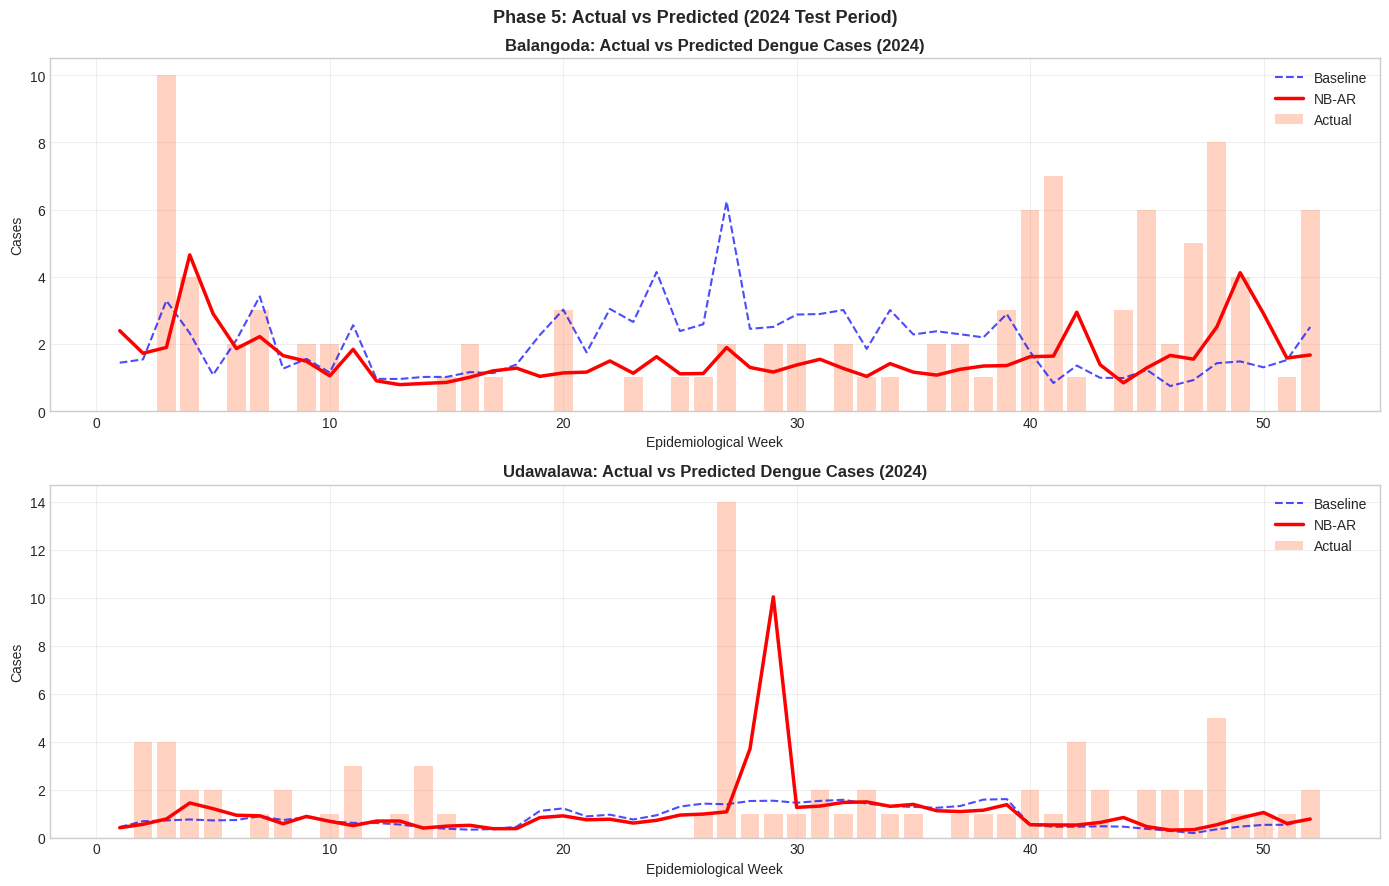

In [10]:
# Actual vs predicted for both MOH areas
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Phase 5: Actual vs Predicted (2024 Test Period)', fontsize=13, fontweight='bold')

for idx, (moh, tdata) in enumerate([('Balangoda', test_bal), ('Udawalawa', test_uda)]):
    weeks = tdata['Week'].values
    actual = tdata['Dengue_Cases'].values
    ax = axes[idx]
    ax.bar(weeks, actual, alpha=0.35, color='coral', label='Actual', width=0.8)
    ax.plot(weeks, tdata['Pred_Model1'], 'b--', lw=1.5, alpha=0.7, label='Baseline')
    ax.plot(weeks, tdata['Pred_Model2'], 'r-', lw=2.5, label='NB-AR')
    ax.set_title(f'{moh}: Actual vs Predicted Dengue Cases (2024)', fontweight='bold')
    ax.set_xlabel('Epidemiological Week')
    ax.set_ylabel('Cases')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('phase5_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## 5.10 Incidence Rate Ratios and Diagnostics

In [21]:
# Incidence Rate Ratios (IRR) via exp(coefficient) and NB fit diagnostics
for moh, model in [('Balangoda', nb_model2_bal), ('Udawalawa', nb_model2_uda)]:
    print(f'  {moh}: NB-AR Model Diagnostics')
    print(f'  Pearson χ²/df: {model.pearson_chi2/model.df_resid:.4f}  (target ≈ 1)')
    print(f'  Deviance/df:   {model.deviance/model.df_resid:.4f}')
    print(f'  AIC:           {model.aic:.2f}')

    print(f'\n  {"Variable":>25} {"IRR":>8} {"p-value":>10} {"95% CI":>20}')
    for var in model.params.index:
        irr = np.exp(model.params[var])
        lo, hi = np.exp(model.conf_int().loc[var, 0]), np.exp(model.conf_int().loc[var, 1])
        p = model.pvalues[var]
        sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else ''))
        print(f'  {var:>25} {irr:>8.4f} {p:>10.4f} [{lo:.3f}, {hi:.3f}] {sig}')

  Balangoda: NB-AR Model Diagnostics
  Pearson χ²/df: 0.7975  (target ≈ 1)
  Deviance/df:   0.9273
  AIC:           706.37

                   Variable      IRR    p-value               95% CI
                      const   0.9842     0.9194 [0.722, 1.341] 
              Rainfall_Lag6   1.0166     0.1719 [0.993, 1.041] 
        Rainfall_Cum4w_Lag1   1.0063     0.2161 [0.996, 1.016] 
                 Rainy_Days   0.9419     0.1996 [0.860, 1.032] 
                  Season_SW   1.0877     0.5358 [0.834, 1.419] 
                  Season_NE   0.9878     0.9379 [0.726, 1.345] 
               Season_Inter   0.9160     0.6054 [0.657, 1.278] 
                Dengue_Lag1   1.1146     0.0033 [1.037, 1.198] **
                Dengue_Lag2   1.0667     0.0795 [0.992, 1.147] 
  Udawalawa: NB-AR Model Diagnostics
  Pearson χ²/df: 1.2006  (target ≈ 1)
  Deviance/df:   0.9710
  AIC:           492.61

                   Variable      IRR    p-value               95% CI
                      const   0.8455

## 5.11 Ljung–Box Residual Autocorrelation Test

In [22]:
# Ljung–Box — tests whether residuals exhibit autocorrelation (H0: independence)
print('Ljung–Box Residual Autocorrelation Test')
print('H0: residuals are independent (no autocorrelation)')
for moh_name, model in [('Balangoda', nb_model2_bal), ('Udawalawa', nb_model2_uda)]:
    print(f'\n{moh_name}:')
    lb = acorr_ljungbox(model.resid_pearson, lags=[5,10,15,20], return_df=True)
    all_ok = True
    for lag_val in lb.index:
        p = lb.loc[lag_val, 'lb_pvalue']
        verdict = 'PASS' if p > 0.05 else 'FAIL (autocorrelated)'
        if p <= 0.05: all_ok = False
        print(f'  Lag {lag_val:>2}: p = {p:.4f}  → {verdict}')
    if all_ok:
        print(f'  → Model residuals show no significant autocorrelation.')
    else:
        print(f'  → Residual autocorrelation remains — limitation noted for future work')
        print(f'    (potential extensions: higher-order AR terms, seasonal AR, or SARIMA variants).')

Ljung–Box Residual Autocorrelation Test
H0: residuals are independent (no autocorrelation)

Balangoda:
  Lag  5: p = 0.0087  → FAIL (autocorrelated)
  Lag 10: p = 0.0002  → FAIL (autocorrelated)
  Lag 15: p = 0.0000  → FAIL (autocorrelated)
  Lag 20: p = 0.0000  → FAIL (autocorrelated)
  → Residual autocorrelation remains — limitation noted for future work
    (potential extensions: higher-order AR terms, seasonal AR, or SARIMA variants).

Udawalawa:
  Lag  5: p = 0.8743  → PASS
  Lag 10: p = 0.3814  → PASS
  Lag 15: p = 0.3121  → PASS
  Lag 20: p = 0.1904  → PASS
  → Model residuals show no significant autocorrelation.


## 5.12 ACF/PACF of Residuals

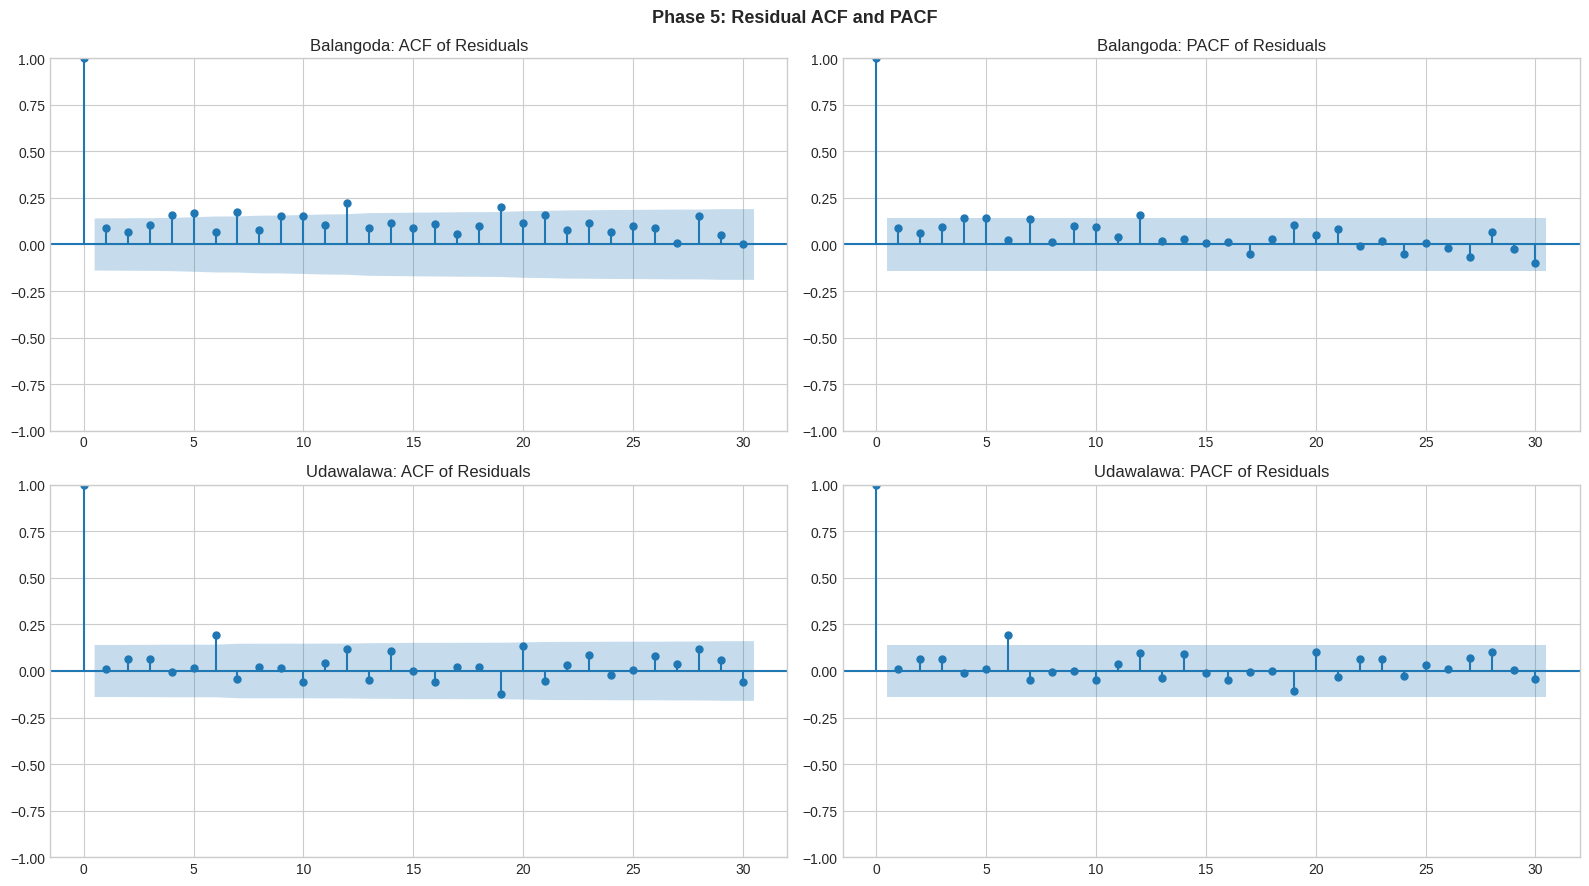

In [13]:
# Autocorrelation and partial autocorrelation functions
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle('Phase 5: Residual ACF and PACF', fontsize=13, fontweight='bold')
for idx, (moh, model) in enumerate([('Balangoda', nb_model2_bal), ('Udawalawa', nb_model2_uda)]):
    plot_acf(model.resid_pearson, ax=axes[idx,0], lags=30, title=f'{moh}: ACF of Residuals')
    plot_pacf(model.resid_pearson, ax=axes[idx,1], lags=30, title=f'{moh}: PACF of Residuals')
plt.tight_layout()
plt.savefig('phase5_residual_acf_pacf.png', dpi=300, bbox_inches='tight')
plt.show()

## 5.13 Poisson vs Negative Binomial Likelihood Ratio Test

In [23]:
# Formal test that NB is preferred over Poisson (H0: no overdispersion)
print('Poisson vs Negative Binomial — Likelihood Ratio Test')
print('H0: equidispersion (α = 0) — if rejected, NB is preferred')
for moh in ['Balangoda', 'Udawalawa']:
    sub = train[train['MOH']==moh]
    y = sub['Dengue_Cases']
    bl = f'Rainfall_Lag{best_lags[moh]}'
    cols = [bl, 'Rainfall_Cum4w_Lag1', 'Rainy_Days',
            'Dengue_Lag1', 'Dengue_Lag2'] + season_cols
    X = sm.add_constant(sub[cols])
    pois = sm.GLM(y, X, family=sm.families.Poisson()).fit()
    nb   = sm.GLM(y, X, family=sm.families.NegativeBinomial()).fit()
    lr = 2 * (nb.llf - pois.llf)
    p = stats.chi2.sf(lr, 1) if lr > 0 else 1.0
    print(f'{moh}: Poisson AIC = {pois.aic:.2f}, NB AIC = {nb.aic:.2f}, LR = {lr:.4f}, p = {p:.6f}')
    if p < 0.05:
        print(f'  → Negative Binomial is significantly preferred.')

Poisson vs Negative Binomial — Likelihood Ratio Test
H0: equidispersion (α = 0) — if rejected, NB is preferred
Balangoda: Poisson AIC = 773.05, NB AIC = 706.37, LR = 66.6794, p = 0.000000
  → Negative Binomial is significantly preferred.
Udawalawa: Poisson AIC = 548.46, NB AIC = 492.61, LR = 55.8415, p = 0.000000
  → Negative Binomial is significantly preferred.


## 5.14 Sensitivity Analysis — Excluding COVID Year (2020)

In [15]:
# Re-fit without 2020 data to assess robustness to pandemic-era reporting anomalies
train_no_covid = train[train['Year'] != 2020].copy()
print(f'Training set excluding 2020: {len(train_no_covid)} observations')

for moh_name in ['Balangoda', 'Udawalawa']:
    sub = train_no_covid[train_no_covid['MOH']==moh_name]
    y = sub['Dengue_Cases']
    bl = f'Rainfall_Lag{best_lags[moh_name]}'
    cols = [bl, 'Rainfall_Cum4w_Lag1', 'Rainy_Days',
            'Dengue_Lag1', 'Dengue_Lag2'] + season_cols
    try:
        nb_nc = sm.GLM(y, sm.add_constant(sub[cols]),
                       family=sm.families.NegativeBinomial()).fit()
        full = nb_model2_bal if moh_name=='Balangoda' else nb_model2_uda
        print(f'\n{moh_name}:')
        print(f'  AIC: Full = {full.aic:.2f}, Excl-2020 = {nb_nc.aic:.2f}')
        for var in ['Dengue_Lag1','Dengue_Lag2']:
            irr_f = np.exp(full.params[var])
            irr_n = np.exp(nb_nc.params[var])
            same_sign = (irr_f>1) == (irr_n>1)
            pct_change = abs(irr_f - irr_n) / irr_f * 100
            status = 'Robust' if same_sign and pct_change < 10 else 'Check'
            print(f'  {var}: IRR full = {irr_f:.3f}, excl-2020 = {irr_n:.3f}  '
                  f'(Δ = {pct_change:.1f}%) → {status}')
    except Exception as e:
        print(f'{moh_name}: Did not converge — {e}')

Training set excluding 2020: 312 observations

Balangoda:
  AIC: Full = 706.37, Excl-2020 = 626.62
  Dengue_Lag1: IRR full = 1.115, excl-2020 = 1.092  (Δ = 2.0%) → Robust
  Dengue_Lag2: IRR full = 1.067, excl-2020 = 1.047  (Δ = 1.8%) → Robust

Udawalawa:
  AIC: Full = 492.61, Excl-2020 = 426.37
  Dengue_Lag1: IRR full = 1.082, excl-2020 = 1.050  (Δ = 3.0%) → Robust
  Dengue_Lag2: IRR full = 1.169, excl-2020 = 1.130  (Δ = 3.3%) → Robust


## 5.15 Naive Baseline Benchmark

In [24]:
# Compare NB-AR against the simplest possible forecast: last week's cases
print("  NAIVE BASELINE BENCHMARK — Does NB-AR beat 'predict last week'?")

for moh, tdata in [('Balangoda', test_bal), ('Udawalawa', test_uda)]:
    actual = tdata['Dengue_Cases'].values
    naive_pred = tdata['Dengue_Lag1'].values
    nbar_pred  = tdata['Pred_Model2'].values

    mae_naive  = mean_absolute_error(actual, naive_pred)
    rmse_naive = np.sqrt(mean_squared_error(actual, naive_pred))
    r2_naive   = r2_score(actual, naive_pred)
    mae_nbar   = mean_absolute_error(actual, nbar_pred)
    rmse_nbar  = np.sqrt(mean_squared_error(actual, nbar_pred))
    r2_nbar    = r2_score(actual, nbar_pred)
    improvement = (mae_naive - mae_nbar) / mae_naive * 100

    print(f'\n{moh}:')
    print(f'  {"Model":<25} {"MAE":>8} {"RMSE":>8} {"R²":>8}')
    print(f'  {"-"*50}')
    print(f'  {"Naive (last-week)":<25} {mae_naive:>8.3f} {rmse_naive:>8.3f} {r2_naive:>8.3f}')
    print(f'  {"NB-AR":<25} {mae_nbar:>8.3f} {rmse_nbar:>8.3f} {r2_nbar:>8.3f}')
    if mae_nbar < mae_naive:
        print(f'  → NB-AR BEATS naive by {improvement:.1f}% on MAE.')
    else:
        print(f'  → Naive predicts better by {-improvement:.1f}% on MAE.')

  NAIVE BASELINE BENCHMARK — Does NB-AR beat 'predict last week'?

Balangoda:
  Model                          MAE     RMSE       R²
  --------------------------------------------------
  Naive (last-week)            2.000    2.774   -0.451
  NB-AR                        1.575    2.272    0.026
  → NB-AR BEATS naive by 21.3% on MAE.

Udawalawa:
  Model                          MAE     RMSE       R²
  --------------------------------------------------
  Naive (last-week)            1.462    2.935   -0.907
  NB-AR                        1.410    2.599   -0.495
  → NB-AR BEATS naive by 3.5% on MAE.


## 5.16 Formal Zone-Interaction Test
---
This section addresses the question: *"Is the rainfall–dengue relationship statistically different between the two climatic zones?"*

We fit a single pooled model that includes:
- A zone indicator (`is_Udawalawa`),
- A primary rainfall lag (Lag6 — Balangoda's best lag, used as a common reference lag for both zones in the interaction model),
- The **interaction** between zone and rainfall,
- Autoregressive and seasonal controls.

If the interaction coefficient is statistically significant, that provides formal statistical evidence that rainfall's effect on dengue differs between the wet and dry zones — the central claim of this thesis.

In [25]:
# Pooled NB model with MOH × Rainfall interaction
combined = train.copy()
combined['is_Udawalawa'] = (combined['MOH'] == 'Udawalawa').astype(int)
combined['Rainfall_Lag6_x_Uda'] = combined['Rainfall_Lag6'] * combined['is_Udawalawa']

interaction_cols = [
    'Rainfall_Lag6',            # rainfall main effect (in reference zone, Balangoda)
    'is_Udawalawa',             # zone main effect
    'Rainfall_Lag6_x_Uda',      # ← the interaction term being tested
    'Dengue_Lag1', 'Dengue_Lag2',
    'Season_SW', 'Season_NE', 'Season_Inter'
]
X_int = combined[interaction_cols].dropna()
y_int = combined.loc[X_int.index, 'Dengue_Cases']

model_int = sm.GLM(y_int, sm.add_constant(X_int),
                   family=sm.families.NegativeBinomial()).fit()
print('Pooled Zone-Interaction Model:')
print(model_int.summary())

interact_p = model_int.pvalues['Rainfall_Lag6_x_Uda']
interact_coef = model_int.params['Rainfall_Lag6_x_Uda']
print(f'  Zone × Rainfall interaction test')
print(f'  Coefficient (Rainfall_Lag6 × is_Udawalawa): {interact_coef:.4f}')
print(f'  p-value: {interact_p:.4f}')
if interact_p < 0.05:
    print(f'  → SIGNIFICANT: rainfall effect differs between zones.')
else:
    print(f'  → Not statistically significant in the pooled multivariate model.')
    print(f'    (But note: Spearman and Granger tests in Phase 4 still show zone-')
    print(f'    specific lag structures and sign differences.)')

Pooled Zone-Interaction Model:
                 Generalized Linear Model Regression Results                  
Dep. Variable:           Dengue_Cases   No. Observations:                  392
Model:                            GLM   Df Residuals:                      384
Model Family:        NegativeBinomial   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -591.45
Date:                Wed, 22 Apr 2026   Deviance:                       372.78
Time:                        18:28:49   Pearson chi2:                     395.
No. Iterations:                    11   Pseudo R-squ. (CS):             0.3489
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
con

## 5.17 Head-to-Head Summary Table

In [27]:
# Consolidated comparison for Phase 7
print('  FINAL COMPARISON: Baseline vs NB-AR (test-set 2024)')

final_results = []
for moh, td, m1, m2 in [('Balangoda', test_bal, nb_model1_bal, nb_model2_bal),
                         ('Udawalawa', test_uda, nb_model1_uda, nb_model2_uda)]:
    actual = td['Dengue_Cases'].values
    p1, p2 = td['Pred_Model1'].values, td['Pred_Model2'].values
    naive = td['Dengue_Lag1'].values

    row_baseline = {
        'MOH': moh, 'Model': 'Baseline', 'AIC': m1.aic,
        'MAE': mean_absolute_error(actual, p1),
        'RMSE': np.sqrt(mean_squared_error(actual, p1)),
        'R2': r2_score(actual, p1)
    }
    row_nbar = {
        'MOH': moh, 'Model': 'NB-AR', 'AIC': m2.aic,
        'MAE': mean_absolute_error(actual, p2),
        'RMSE': np.sqrt(mean_squared_error(actual, p2)),
        'R2': r2_score(actual, p2)
    }
    row_naive = {
        'MOH': moh, 'Model': 'Naive', 'AIC': np.nan,
        'MAE': mean_absolute_error(actual, naive),
        'RMSE': np.sqrt(mean_squared_error(actual, naive)),
        'R2': r2_score(actual, naive)
    }
    final_results.extend([row_baseline, row_nbar, row_naive])

results_df = pd.DataFrame(final_results)
print(results_df.round(3).to_string(index=False))

# Save for Phase 7
results_df.to_csv('phase5_final_results.csv', index=False)
test_bal.to_csv('predictions_2024_balangoda.csv', index=False)
test_uda.to_csv('predictions_2024_udawalawa.csv', index=False)
print('\nSaved: phase5_final_results.csv, predictions_2024_*.csv')

for f in ['phase5_final_results.csv','predictions_2024_balangoda.csv',
          'predictions_2024_udawalawa.csv','phase5_predictions.png',
          'phase5_residual_acf_pacf.png']:
    try:
        files.download(f)
        print(f'Downloaded: {f}')
    except Exception:
        pass


  FINAL COMPARISON: Baseline vs NB-AR (test-set 2024)
      MOH    Model     AIC   MAE  RMSE     R2
Balangoda Baseline 756.532 1.858 2.488 -0.167
Balangoda    NB-AR 706.374 1.575 2.272  0.026
Balangoda    Naive     NaN 2.000 2.774 -0.451
Udawalawa Baseline 496.001 1.295 2.250 -0.120
Udawalawa    NB-AR 492.614 1.410 2.599 -0.495
Udawalawa    Naive     NaN 1.462 2.935 -0.907

Saved: phase5_final_results.csv, predictions_2024_*.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: phase5_final_results.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: phase5_predictions.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: phase5_residual_acf_pacf.png
